<a href="https://colab.research.google.com/github/SugiShanmu/Machine-Learning-/blob/main/LogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Age  Income_k  Gender Has_CreditCard  Approved
0   22        25    Male             No         0
1   45        80  Female            Yes         1
2   35        50  Female            Yes         1
3   52        90    Male            Yes         1
4   28        30    Male             No         0

Accuracy: 100.0%

Confusion Matrix:
[[2 0]
 [0 3]]

Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



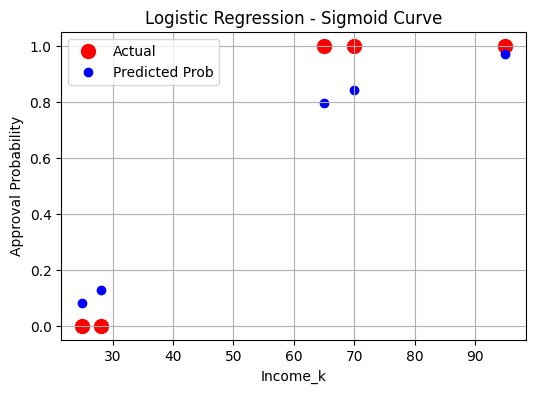


Generated: logistic_regression_plot.png

After Scaling + Encoding, shape: (15, 4)
First row (scaled age, income + encoded gender, card): [-1.71630554 -1.64905954  1.          0.        ]


<Figure size 640x480 with 0 Axes>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1. SAMPLE DATA - Customer Churn / Loan Approval
data = {
    'Age': [22, 45, 35, 52, 28, 40, 60, 30, 48, 25, 38, 55, 33, 42, 29],
    'Income_k': [25, 80, 50, 90, 30, 65, 100, 45, 85, 28, 60, 95, 55, 70, 35],
    'Gender': ['Male','Female','Female','Male','Male','Female','Male','Female','Male','Female','Male','Female','Male','Female','Male'],
    'Has_CreditCard': ['No','Yes','Yes','Yes','No','Yes','Yes','No','Yes','No','Yes','Yes','No','Yes','No'],
    'Approved': [0,1,1,1,0,1,1,0,1,0,1,1,0,1,0] # 0=No, 1=Yes
}
df = pd.DataFrame(data)
print(df.head())

# 2. X, y split
X = df.drop('Approved', axis=1)
y = df['Approved']

# 3. PREPROCESSING
numeric_features = ['Age', 'Income_k']
categorical_features = ['Gender', 'Has_CreditCard']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features), # Feature Scaling + Normalization
    ('cat', OneHotEncoder(drop='first'), categorical_features) # Encoding
])

# 4. PIPELINE
model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

# 5. TRAIN TEST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. TRAIN
model.fit(X_train, y_train)

# 7. PREDICT
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nReport:")
print(classification_report(y_test, y_pred))

# 8. CHART - Sigmoid / Decision
plt.figure(figsize=(6,4))
plt.scatter(X_test['Income_k'], y_test, color='red', label='Actual', s=100)
plt.scatter(X_test['Income_k'], y_proba, color='blue', label='Predicted Prob')
plt.xlabel("Income_k")
plt.ylabel("Approval Probability")
plt.title("Logistic Regression - Sigmoid Curve")
plt.legend()
plt.grid(True)
plt.show()

# Save chart
plt.savefig("logistic_regression_plot.png")
print("\nGenerated: logistic_regression_plot.png")

# 9. Show scaled example
X_scaled = model.named_steps['preprocessor'].transform(X)
print(f"\nAfter Scaling + Encoding, shape: {X_scaled.shape}")
print("First row (scaled age, income + encoded gender, card):", X_scaled[0])